In [28]:
import matplotlib.pyplot as plt

def plot_1(title, x_label, results):
  plt.figure(figsize=(10, 5))

  for label, values in results.items():
      x = sorted(values.keys())
      y = [values[k] for k in x]
      if label.startswith("c"):
        if label[3] == "1":
          label = "C - MPI (" + label[3] + "n x " + label[5] + "c)"
        elif label[3] == "8":
          label = "C - OpenMP (" + label[3] + "n x " + label[5] + "c)"
        else:
          label = "C - hybrid (" + label[3] + "n x " + label[5] + "c)"
        plt.plot(x, y, marker='.', label=label)
      else:        
        label = "Java - PCJ (" + label[3] + "n x " + label[5] + "c)"
        plt.plot(x, y, marker='.', linestyle='--', label=label)

  plt.xlabel(x_label)
  plt.ylabel("Elapsed time (s)")
  plt.title(title)
  plt.legend()
  plt.grid()

  plt.show()

In [29]:
def plot_2(title, action, results):
  plt.figure(figsize=(10, 5))

  all_n = set()
  for config_results in results.values():
    all_n.update(config_results.keys())

  for n in sorted(all_n):
    x_keys = list(filter(lambda k: k.startswith("c"), results.keys()))
    xy_pairs = [(k, results[k].get(n)) for k in x_keys]
    xy_pairs = [(k, v) for k, v in xy_pairs if v is not None]
    
    if xy_pairs:
      xy_pairs.sort(key=lambda p: p[0])
      x = [k[2:] for k, v in xy_pairs]
      y = [v for k, v in xy_pairs]
      plt.plot(x, y, marker='.', label="C ("+str(n)+f" {action})")
    
    xj_keys = list(filter(lambda k: k.startswith("j"), results.keys()))
    xyj_pairs = [(k, results[k].get(n)) for k in xj_keys]
    xyj_pairs = [(k, v) for k, v in xyj_pairs if v is not None]
    
    if xyj_pairs:
      xyj_pairs.sort(key=lambda p: p[0])
      xj = [k[2:] for k, v in xyj_pairs]
      yj = [v for k, v in xyj_pairs]
      plt.plot(xj, yj, marker='.', label="Java ("+str(n)+f" {action})", linestyle='--')

  plt.xlabel(f"Total {action}")
  plt.ylabel("Elapsed time (s)")
  plt.title(title)
  plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
  plt.grid()

  plt.show()

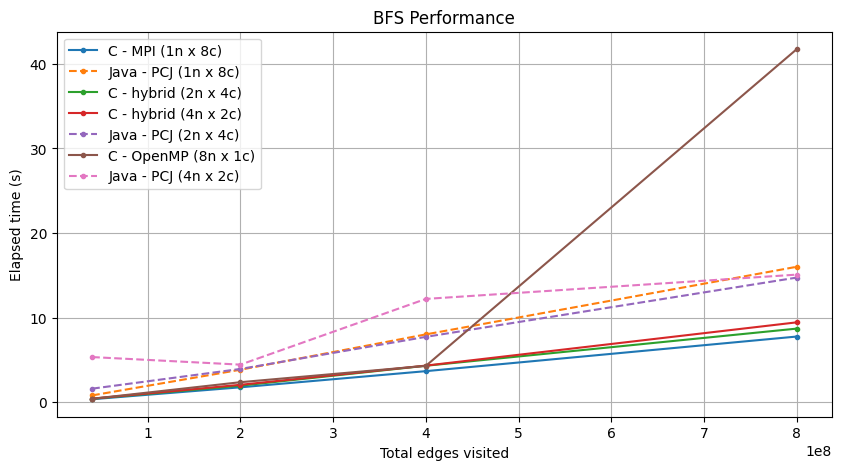

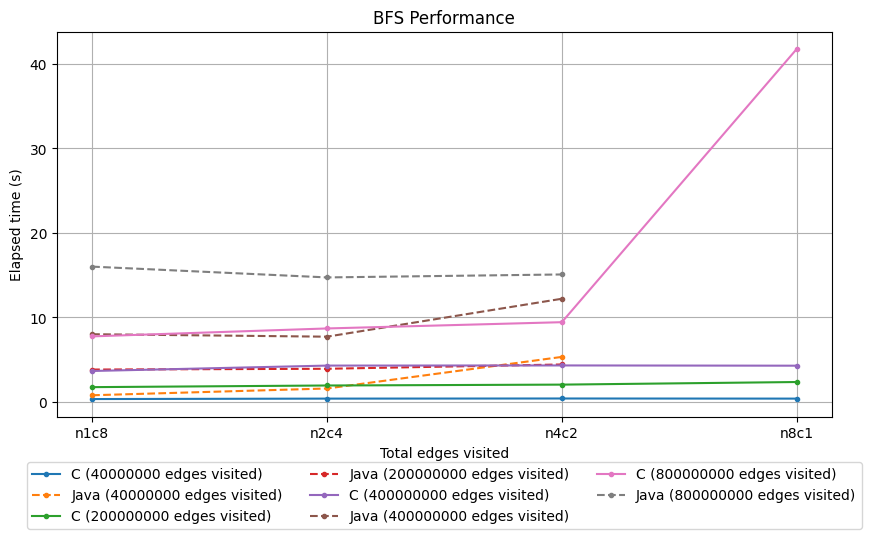

In [30]:
import matplotlib.pyplot as plt
import re
import os

results_path = "mpr/proj1_results/run_at_2026-03-30_15-07-58-423/jobs"

results = {}

for filename in os.listdir(results_path):
  if filename.endswith(".err"):
    continue
  with open(os.path.join(results_path, filename), "r") as f:
    if filename.find("gr") != -1:
      if filename.startswith("c"):
        time_pattern = re.compile(r"Elapsed time = ([\d.]+) s")
        edges_pattern = re.compile(r"Total edges visited = (\d+)")
      else:
        time_pattern = re.compile(r"Time: ([\d.]+) s")
        edges_pattern = re.compile(r"Edges: (\d+)")

      text = f.read()

      times = time_pattern.findall(text)
      edges = edges_pattern.findall(text)


      if not times: continue

      result = {}

      for t, e in zip(times, edges):
          result[int(e)] = float(t)

      results[filename[0] + "_" + filename[4:8]] = result


plot_1("BFS Performance", "Total edges visited", results)
plot_2("BFS Performance", "edges visited", results)

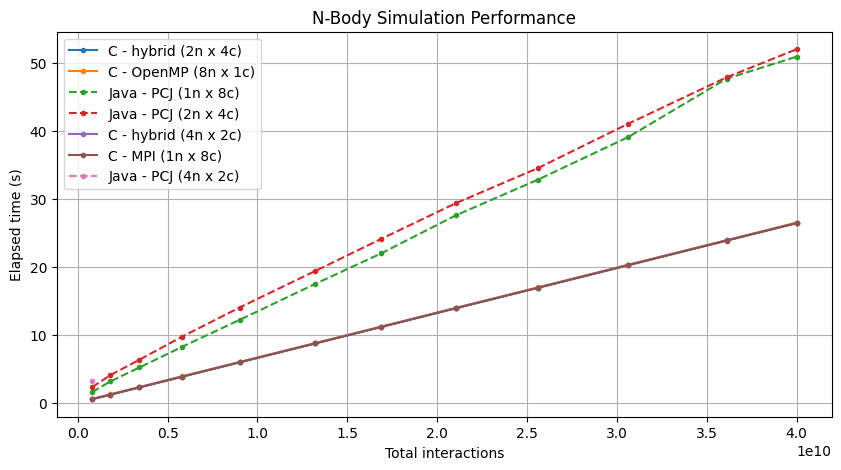

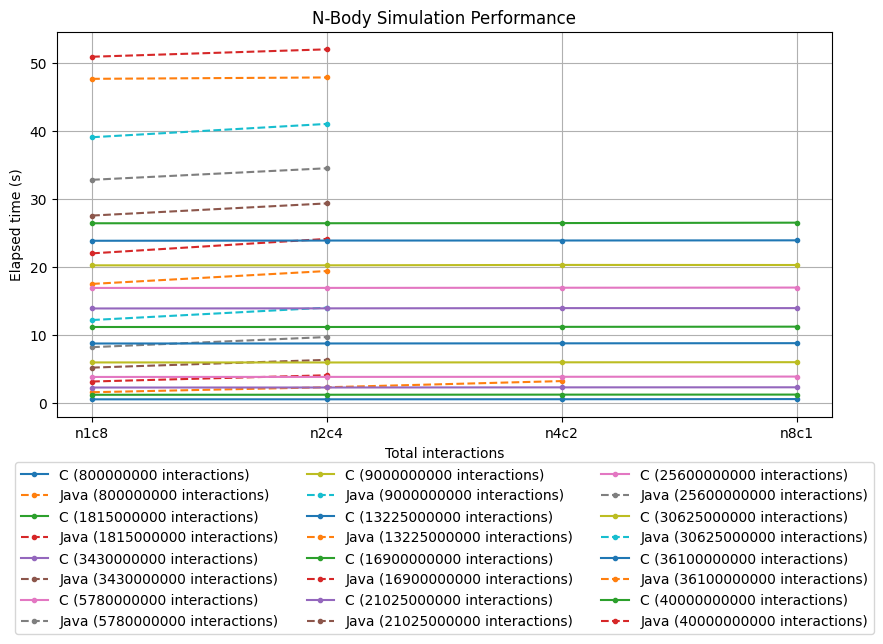

In [31]:
import matplotlib.pyplot as plt
import re
import os

results_path = "mpr/proj1_results/run_at_2026-03-30_15-07-58-423/jobs"

results = {}

for filename in os.listdir(results_path):
  if filename.endswith(".err"):
    continue
  with open(os.path.join(results_path, filename), "r") as f:
    if filename.find("nb") != -1:
      text = f.read()
      if filename.startswith("c"):
        time_pattern = re.compile(r"Elapsed time = ([\d.]+) s")
        edges_pattern = re.compile(r"Total interactions = (\d+)")

        times = time_pattern.findall(text)
        edges = edges_pattern.findall(text)
      else:
        time_pattern = re.compile(r"Czas calkowity: ([\d.]+) s")
        edges_pattern = re.compile(r"Symulacja (\d+)")
        edges_pattern2 = re.compile(r"przez (\d+)")

        times = time_pattern.findall(text)
        bodies = edges_pattern.findall(text)
        iterations = edges_pattern2.findall(text)

        edges = [str(int(b) * int(b) * int(i)) for b, i in zip(bodies, iterations)]

      if not times: continue

      result = {}

      for t, e in zip(times, edges):
          result[int(e)] = float(t)

      results[filename[0] + "_" + filename[4:8]] = result

plot_1("N-Body Simulation Performance", "Total interactions", results)
plot_2("N-Body Simulation Performance", "interactions", results)

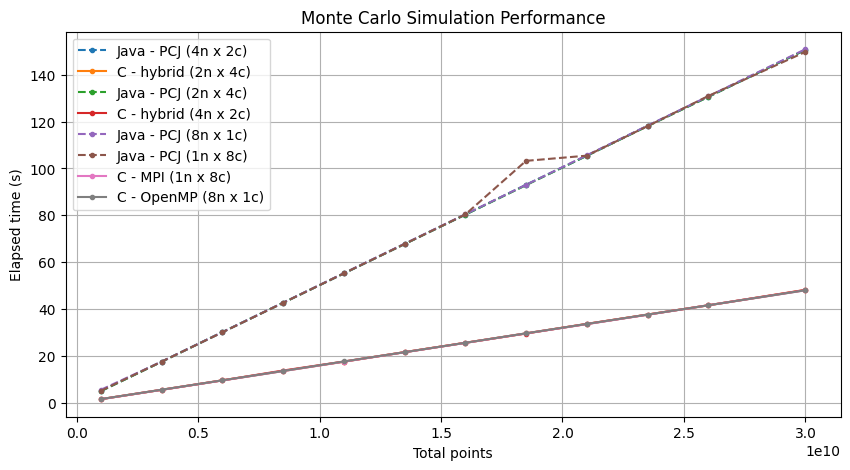

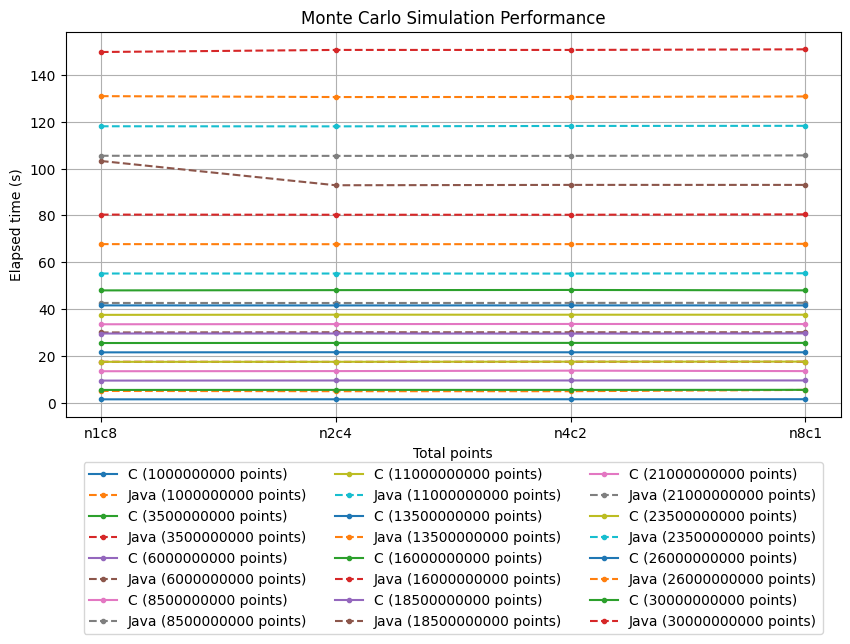

In [32]:
import matplotlib.pyplot as plt
import re
import os

results_path = "mpr/proj1_results/run_at_2026-03-30_15-07-58-423/jobs"

results = {}

for filename in os.listdir(results_path):
  if filename.endswith(".err"):
    continue
  with open(os.path.join(results_path, filename), "r") as f:
    if filename.find("mn") != -1 or filename.find("mc") != -1:
      text = f.read()
      time_pattern = re.compile(r"Elapsed time = ([\d.]+) s")
      edges_pattern = re.compile(r"Total points = (\d+)")

      times = time_pattern.findall(text)
      edges = edges_pattern.findall(text)

      if not times: continue

      result = {}

      for t, e in zip(times, edges):
          result[int(e)] = float(t)

      results[filename[0] + "_" + filename[4:8]] = result

plot_1("Monte Carlo Simulation Performance", "Total points", results)
plot_2("Monte Carlo Simulation Performance", "points", results)